# Determining optimum history length
## Entropy rate

**Aim:**  
Determine the optimum history length for entropy-rate estimation.  
**Method:**  
Each subject has its own theoretical (first-order Markov) entropy rate, so the
theoretical-vs-surrogate comparison is done **at subject level**: for each subject and
each *k* in ``[kmin, kmax]``, generate ``n_surr`` first-order Markov surrogates matched
to that subject's transition matrix, estimate their entropy rate at history length *k*,
and express it **relative to that subject's own theoretical entropy rate** (so the
theoretical value is normalized to 1.0). This gives one normalized value per subject per
*k*. The statistical test (one-sample t-test against 1.0, plus Cohen's *d*) is then run
**across the n=201 subject-level normalized values** at each *k* -- not pooled across
individual surrogate draws, and not averaged over 201 separate per-subject tests.

Run across **all** MPILMBB `*_EC_*.npy` files (all subjects, all smoothing conditions),
each truncated to `n_max=100000` samples.</cell id="cell-1">


In [1]:
import numpy as np
from scipy.stats import ttest_1samp
import mstsa

print(mstsa.__version__)

0.4.0


In [2]:
import glob

data_path = "../data/mpilmbb"

# Smoothing (pre-processing) condition to analyze: one of 'b1', 'b3', 'b9', 'ip', or
# 'all' to pool every condition together.
smoothing = 'b1'
_SMOOTHING_CHOICES = ('b1', 'b3', 'b9', 'ip', 'all')
if smoothing not in _SMOOTHING_CHOICES:
    raise ValueError(f"smoothing must be one of {_SMOOTHING_CHOICES}, got {smoothing!r}")

pattern = "*_EC_*.npy" if smoothing == 'all' else f"*_EC_ms_{smoothing}_K4_*.npy"
files = sorted(glob.glob(f"{data_path}/{pattern}"))
print(f"smoothing={smoothing!r}: {len(files)} EC files")

#x0 = np.load(files[0])
#print(files[0].split('/')[-1], x0.shape, x0.dtype, np.unique(x0))

smoothing='b1': 201 EC files


In [3]:
n_max = 100000
n_surr = 10
kmin = 1
kmax = 7
ks = np.arange(kmin, kmax + 1)
n_k = len(ks)

import os

cache_dir = "../data/cache/optimum_history_length"
os.makedirs(cache_dir, exist_ok=True)
cache_file = os.path.join(cache_dir,
                           f"er_kmax_sweep_{smoothing}_nmax{n_max}_nsurr{n_surr}_k{kmin}-{kmax}.npz")

if os.path.exists(cache_file):
    d = np.load(cache_file)
    h_norm = {k: d[f"h_norm_k{k}"] for k in ks}
    lzc_norm = d["lzc_norm"]
    print(f"loaded cached results from {cache_file}")
else:
    # One normalized value per subject per k: mean(surrogate ER) / subject's theoretical ER.
    # The subject's own theoretical value is thus normalized to 1.0, making values comparable
    # across subjects despite each having a different absolute entropy rate.
    h_norm = {k: [] for k in ks}

    # LZ76 has no history-length parameter, so kmax is not a meaningful independent variable
    # for it -- one normalized value per subject (not per k). mstsa.lz76 returns the
    # normalized complexity c(n)*log2(n)/n, a compression-rate estimate that -- by the
    # Lempel-Ziv source coding theorem -- converges to the entropy rate h for large n, so
    # it's compared against the same theoretical entropy rate h_theo used for ER.
    lzc_norm = []

    for i, f in enumerate(files):
        x = np.load(f)[:n_max]
        K = len(set(x))
        nx = len(x)

        T = mstsa.tpm_cond(x, K)
        p = mstsa.pmf(x, K)
        h_theo = mstsa.entropy_rate_mc(x)  # theoretical entropy rate for this subject

        # generate the surrogate set once per subject -- shared across all k for ER (so the
        # k-sweep isn't confounded by re-drawing new surrogates at every k), and used as-is
        # for LZC (which doesn't depend on k at all)
        surrs = [mstsa.mc_sample_path(T=T, n=nx, p=p) for _ in range(n_surr)]

        lzc_surr = np.array([mstsa.lz76(y) for y in surrs])
        lzc_norm.append(lzc_surr.mean() / h_theo)

        for k in ks:
            h_surr = np.array([mstsa.entropy_rate(y, K, kmax=k, doplot=False)[0] for y in surrs])
            h_norm[k].append(h_surr.mean() / h_theo)

        #if (i+1) % 100 == 0 or i == len(files)-1:
        print(f"[{i+1}/{len(files)}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    lzc_norm = np.array(lzc_norm)
    save_dict = {f"h_norm_k{k}": np.array(h_norm[k]) for k in ks}
    save_dict["lzc_norm"] = lzc_norm
    np.savez(cache_file, **save_dict)

loaded cached results from ../data/cache/optimum_history_length/er_kmax_sweep_b1_nmax100000_nsurr10_k1-7.npz


In [4]:
import os
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ttest_1samp

alpha = 0.05

# One-sample t-test of the n=201 subject-level normalized values against 1.0 (the
# theoretical value), plus Cohen's d, computed once per k across all subjects.
stats_k = {}
print(f"{'k':>3s} {'mean dev %':>11s} {'median dev %':>13s} {'t':>7s} {'p':>10s} {'d':>7s}  sig")
for k in ks:
    vals = np.array(h_norm[k])  # n=201
    dev_pct = (vals - 1.0) * 100
    t_stat, pval = ttest_1samp(vals, 1.0)
    d = (vals.mean() - 1.0) / vals.std(ddof=1)
    stats_k[k] = dict(t=t_stat, p=pval, d=d)
    sig = '*' if pval < alpha else 'ns'
    print(f"{k:3d} {dev_pct.mean():11.2f} {np.median(dev_pct):13.2f} {t_stat:7.2f} {pval:10.3g} {d:7.3f}  {sig}")

  k  mean dev %  median dev %       t          p       d  sig
  1       -0.07         -0.12   -2.73    0.00693  -0.192  *
  2       -0.15         -0.21   -5.67   4.96e-08  -0.400  *
  3       -0.39         -0.44  -14.51   4.47e-33  -1.024  *
  4       -0.88         -0.92  -32.83   1.74e-82  -2.316  *
  5       -1.71         -1.76  -61.99  1.57e-132  -4.372  *
  6       -2.91         -2.96  -97.81  7.57e-171  -6.899  *
  7       -4.49         -4.55 -128.52  3.45e-194  -9.065  *


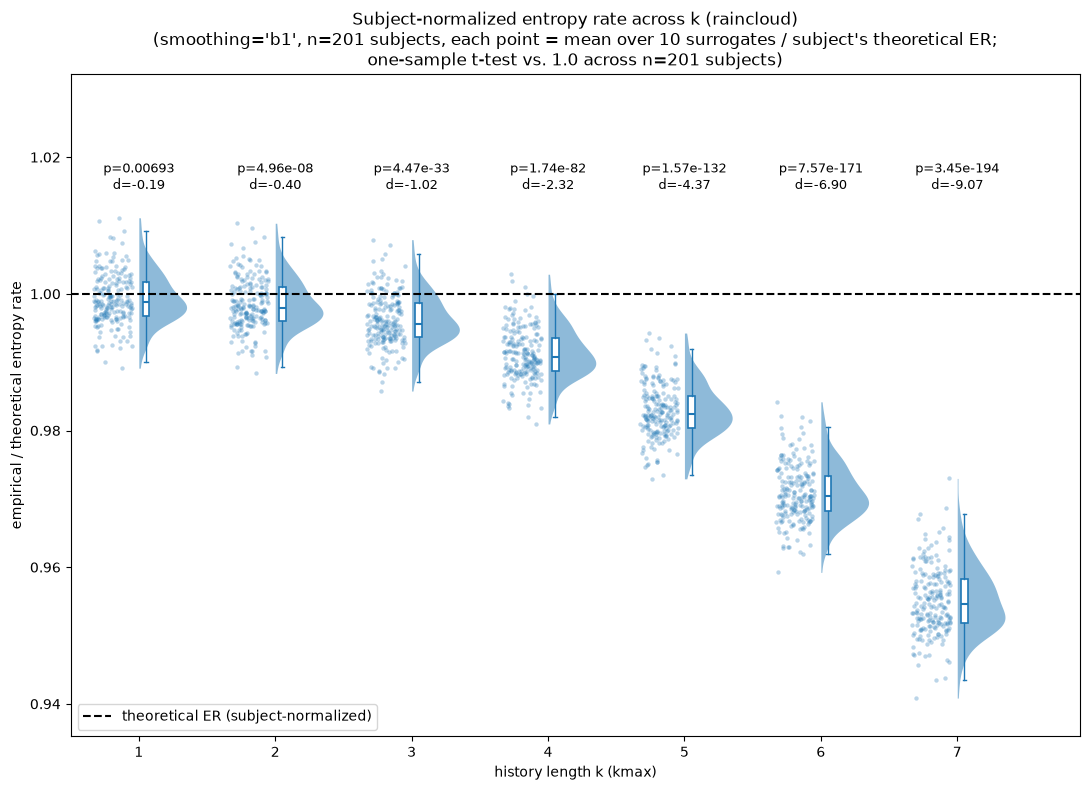

In [5]:
def raincloud(ax, x0, vals, color, violin_width=0.35, box_width=0.05,
              rain_spread=0.28, rain_gap=0.05, alpha_rain=0.3):
    """One raincloud (half-violin + boxplot + jittered raw points) at x position x0."""
    vals = np.asarray(vals)

    # cloud: half-violin (density), offset to the right of x0
    kde = gaussian_kde(vals)
    ys = np.linspace(vals.min(), vals.max(), 200)
    dens = kde(ys)
    dens = dens / dens.max() * violin_width
    ax.fill_betweenx(ys, x0, x0 + dens, color=color, alpha=0.5, zorder=2, linewidth=0)

    # umbrella handle: compact boxplot, just right of x0
    ax.boxplot([vals], positions=[x0 + violin_width * 0.15], widths=box_width,
               orientation='vertical', patch_artist=True, showfliers=False, zorder=4,
               boxprops=dict(facecolor='white', edgecolor=color, linewidth=1.2),
               medianprops=dict(color=color, linewidth=1.5),
               whiskerprops=dict(color=color), capprops=dict(color=color))

    # rain: jittered raw points (one per subject), to the left of x0
    jitter = rng.random(len(vals)) * rain_spread
    ax.scatter(x0 - rain_gap - jitter, vals, s=10, color=color, alpha=alpha_rain,
               zorder=1, linewidths=0)


rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(11, 8))
ax.axhline(1.0, color='k', ls='--', label='theoretical ER (subject-normalized)', zorder=5)

for k in ks:
    raincloud(ax, k, h_norm[k], color='tab:blue')

ax.set_xticks(ks)
ax.set_xticklabels([str(k) for k in ks])
ax.set_xlim(ks[0] - 0.5, ks[-1] + 0.9)

all_vals = np.concatenate([h_norm[k] for k in ks])
ymax, ymin = all_vals.max(), all_vals.min()
span = ymax - ymin
ax.set_ylim(ymin - 0.08 * span, ymax + 0.30 * span)
for k in ks:
    st = stats_k[k]
    ax.annotate(f"p={st['p']:.3g}\nd={st['d']:.2f}", (k, ymax + 0.06 * span), textcoords="data",
                ha='center', fontsize=9)

ax.set_xlabel('history length k (kmax)')
ax.set_ylabel('empirical / theoretical entropy rate')
ax.set_title(f'Subject-normalized entropy rate across k (raincloud)\n'
             f'(smoothing={smoothing!r}, n={len(files)} subjects, each point = mean over '
             f'{n_surr} surrogates / subject\'s theoretical ER;\n'
             f'one-sample t-test vs. 1.0 across n={len(files)} subjects)')
ax.legend(loc='lower left')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/optimum_history_length_er.png', dpi=150, bbox_inches='tight')
plt.show()

## Lempel-Ziv complexity

`mstsa.lz76` takes no history-length argument -- it's a single complexity estimate per
sequence, so **kmax is not a meaningful independent variable for it** (unlike entropy
rate, which is explicitly parameterized by history length). Rather than plotting it
against k, each subject contributes one normalized value: `mean(LZC over the same n_surr
surrogates used above) / h_theo`. `mstsa.lz76` returns the normalized complexity
`c(n)*log2(n)/n`, which -- by the Lempel-Ziv source coding theorem -- converges to the
entropy rate `h` as `n -> infinity`, so it's compared against the same theoretical
entropy rate `h_theo` used for ER, and the result is a single subject-level distribution
(n=201), not one raincloud per k.

In [6]:
vals = np.array(lzc_norm)  # n=201, one value per subject -- no k dependence
t_stat, pval = ttest_1samp(vals, 1.0)
d = (vals.mean() - 1.0) / vals.std(ddof=1)
sig = '*' if pval < alpha else 'ns'
print(f"{'mean dev %':>11s} {'median dev %':>13s} {'t':>7s} {'p':>10s} {'d':>7s}  sig")
print(f"{(vals.mean() - 1) * 100:11.2f} {(np.median(vals) - 1) * 100:13.2f} "
      f"{t_stat:7.2f} {pval:10.3g} {d:7.3f}  {sig}")

 mean dev %  median dev %       t          p       d  sig
       1.97          1.96   66.24  5.05e-138   4.672  *


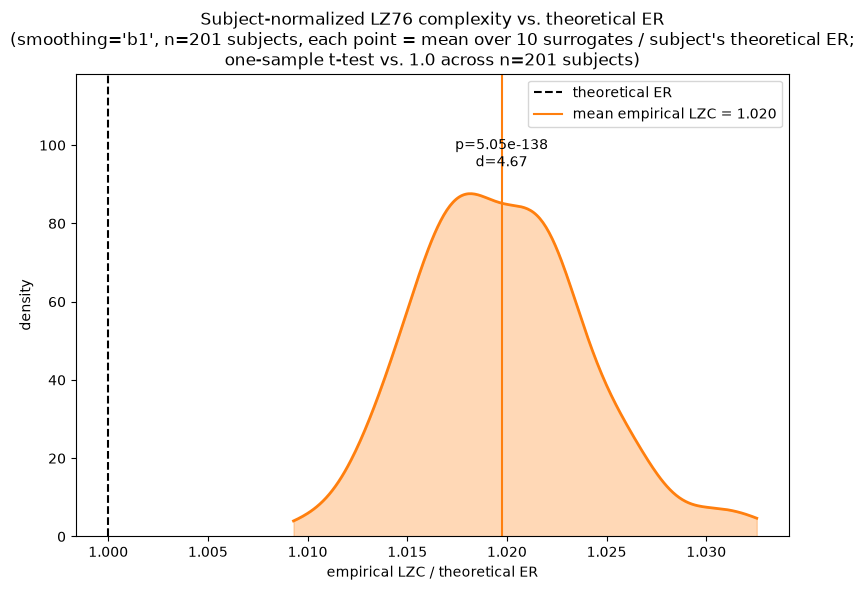

In [7]:
kde = gaussian_kde(vals)
xs = np.linspace(vals.min(), vals.max(), 300)
dens = kde(xs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(xs, dens, color='tab:orange', lw=2)
ax.fill_between(xs, dens, color='tab:orange', alpha=0.3)
ax.axvline(1.0, color='k', ls='--', label='theoretical ER')
ax.axvline(vals.mean(), color='tab:orange', ls='-', lw=1.5,
           label=f'mean empirical LZC = {vals.mean():.3f}')

ax.set_ylim(0, dens.max() * 1.35)
ax.annotate(f"p={pval:.3g}\nd={d:.2f}", (vals.mean(), dens.max() * 1.08), textcoords="data",
            ha='center', fontsize=10)

ax.set_xlabel('empirical LZC / theoretical ER')
ax.set_ylabel('density')
ax.set_title(f'Subject-normalized LZ76 complexity vs. theoretical ER\n'
             f'(smoothing={smoothing!r}, n={len(files)} subjects, each point = mean over '
             f'{n_surr} surrogates / subject\'s theoretical ER;\n'
             f'one-sample t-test vs. 1.0 across n={len(files)} subjects)')
ax.legend()
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/optimum_history_length_lzc.png', dpi=150, bbox_inches='tight')
plt.show()

## Entropy rate and LZ76 vs. sequence length (fixed kmax=3)

Same subject-level normalization as before, but now the independent variable is
**surrogate sequence length**, not history length: `kmax` is fixed at 3 for the entropy
rate estimator, and each subject's transition matrix `T`/`p`/`h_theo` (estimated once
from their full real sequence) is used to generate surrogates at 20 log-spaced lengths
between 1,000 and 100,000 samples (`mstsa.mc_sample_path` can simulate a surrogate of any
requested length regardless of how long the real recording is). `entropy_rate` is
computed on all `n_surr=10` surrogate draws at each length; `lz76` reuses the first
`n_surr_lzc=3` of the same draws (its cost grows steeply, ~O(n^1.7), with sequence
length, so using all 10 at every length for all 201 subjects would take over an hour).
Both are normalized by the *same* `h_theo` reference (per the LZ76-converges-to-entropy-
rate argument used earlier), so the two curves are directly comparable on one plot. This
asks: how much data does each estimator need before its bias becomes negligible?

In [8]:
kmax_fixed = 3
lengths = np.unique(np.logspace(np.log10(1000), np.log10(100000), 20).astype(int))

# LZ76's cost grows steeply with sequence length (~O(n^1.7), not linear -- e.g. ~0.85s
# per call at n=100000), so computing it on all n_surr=10 surrogates at every length for
# all 201 subjects would take over an hour. Reuse only the first n_surr_lzc of the
# already-generated surrogates for LZ76 (no extra random draws needed), keeping ER on
# the full n_surr for a tighter mean.
n_surr_lzc = 3

cache_file_len = os.path.join(
    cache_dir,
    f"er_lzc_length_sweep_{smoothing}_nmax{n_max}_nsurr{n_surr}_nsurrlzc{n_surr_lzc}_"
    f"kmaxfixed{kmax_fixed}_L{lengths[0]}-{lengths[-1]}-{len(lengths)}.npz")

if os.path.exists(cache_file_len):
    d = np.load(cache_file_len)
    lengths = d["lengths"]
    len_norm = {L: d[f"len_norm_L{L}"] for L in lengths}
    lzc_len_norm = {L: d[f"lzc_len_norm_L{L}"] for L in lengths}
    print(f"loaded cached results from {cache_file_len}")
else:
    len_norm = {L: [] for L in lengths}
    lzc_len_norm = {L: [] for L in lengths}  # same length sweep, LZ76 instead of ER(kmax=3)

    for i, f in enumerate(files):
        x = np.load(f)[:n_max]
        K = len(set(x))

        T = mstsa.tpm_cond(x, K)
        p = mstsa.pmf(x, K)
        h_theo = mstsa.entropy_rate_mc(x)  # fixed reference, from the full real sequence

        for L in lengths:
            surrs_L = [mstsa.mc_sample_path(T=T, n=int(L), p=p) for _ in range(n_surr)]
            h_surr = np.array([mstsa.entropy_rate(y, K, kmax=kmax_fixed, doplot=False)[0]
                                for y in surrs_L])
            lzc_surr = np.array([mstsa.lz76(y) for y in surrs_L[:n_surr_lzc]])
            len_norm[L].append(h_surr.mean() / h_theo)
            lzc_len_norm[L].append(lzc_surr.mean() / h_theo)

        #if (i+1) % 100 == 0 or i == len(files)-1:
        print(f"[{i+1}/{len(files)}] {f.split('/')[-1]}", end="\r")

    print("\ndone.")
    save_dict = {"lengths": lengths}
    save_dict.update({f"len_norm_L{L}": np.array(len_norm[L]) for L in lengths})
    save_dict.update({f"lzc_len_norm_L{L}": np.array(lzc_len_norm[L]) for L in lengths})
    np.savez(cache_file_len, **save_dict)

loaded cached results from ../data/cache/optimum_history_length/er_lzc_length_sweep_b1_nmax100000_nsurr10_nsurrlzc3_kmaxfixed3_L1000-100000-20.npz


In [9]:
stats_len = {}
stats_lzc_len = {}
print(f"{'length':>8s} {'ER dev %':>9s} {'ER p':>10s} {'ER d':>7s}  sig  "
      f"{'LZC dev %':>10s} {'LZC p':>10s} {'LZC d':>7s}  sig")
for L in lengths:
    vals = np.array(len_norm[L])  # n=201
    t_stat, pval = ttest_1samp(vals, 1.0)
    d = (vals.mean() - 1.0) / vals.std(ddof=1)
    stats_len[L] = dict(mean=vals.mean(), sem=vals.std(ddof=1) / np.sqrt(len(vals)),
                         t=t_stat, p=pval, d=d)
    sig = '*' if pval < alpha else 'ns'

    lvals = np.array(lzc_len_norm[L])
    lt_stat, lpval = ttest_1samp(lvals, 1.0)
    ld = (lvals.mean() - 1.0) / lvals.std(ddof=1)
    stats_lzc_len[L] = dict(mean=lvals.mean(), sem=lvals.std(ddof=1) / np.sqrt(len(lvals)),
                             t=lt_stat, p=lpval, d=ld)
    lsig = '*' if lpval < alpha else 'ns'

    print(f"{L:8d} {(vals.mean() - 1) * 100:9.2f} {pval:10.3g} {d:7.3f}  {sig:>3s}  "
          f"{(lvals.mean() - 1) * 100:10.2f} {lpval:10.3g} {ld:7.3f}  {lsig}")

  length  ER dev %       ER p    ER d  sig   LZC dev %      LZC p   LZC d  sig
    1000     -4.72  3.29e-108  -3.240    *        4.31   4.09e-49   1.399  *
    1274     -3.87   9.5e-102  -2.985    *        4.14   1.06e-55   1.562  *
    1623     -2.99   6.31e-85  -2.394    *        3.77   5.59e-56   1.569  *
    2069     -2.41   7.12e-87  -2.457    *        3.70   1.61e-59   1.660  *
    2636     -2.02   2.57e-79  -2.217    *        3.41   6.23e-58   1.619  *
    3359     -1.66   3.98e-75  -2.091    *        3.11   1.08e-67   1.879  *
    4281     -1.31   2.41e-68  -1.897    *        2.93   2.18e-66   1.843  *
    5455     -1.08   1.72e-56  -1.582    *        2.72   7.12e-72   1.996  *
    6951     -0.82    4.5e-57  -1.597    *        2.58   4.24e-86   2.432  *
    8858     -0.65   1.76e-42  -1.241    *        2.43   4.96e-85   2.397  *
   11288     -0.51   9.24e-39  -1.154    *        2.19   4.45e-84   2.366  *
   14384     -0.45   7.74e-38  -1.133    *        2.03   9.16e-86   2.421 

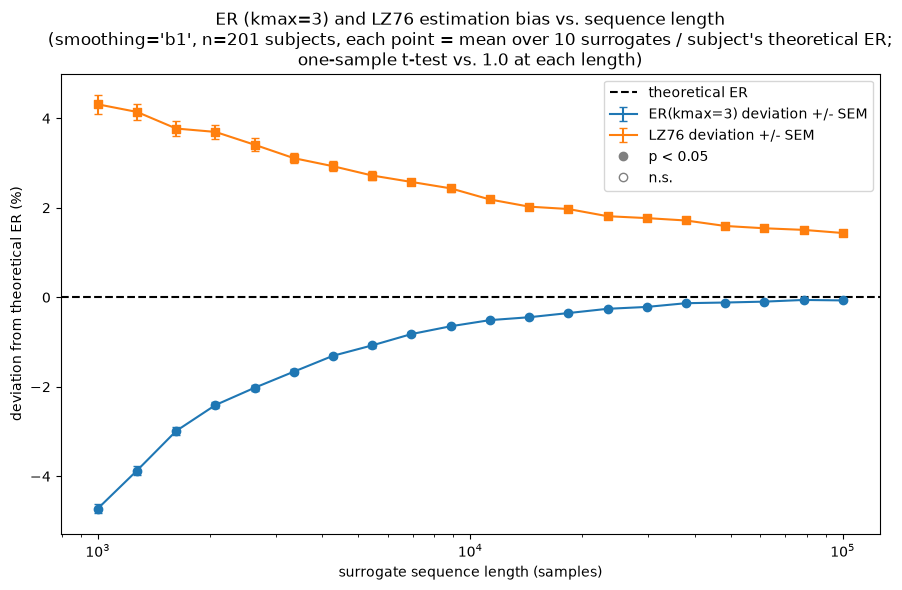

In [10]:
mean_dev = np.array([(stats_len[L]['mean'] - 1) * 100 for L in lengths])
sem_dev = np.array([stats_len[L]['sem'] * 100 for L in lengths])
sig_mask = np.array([stats_len[L]['p'] < alpha for L in lengths])

lzc_mean_dev = np.array([(stats_lzc_len[L]['mean'] - 1) * 100 for L in lengths])
lzc_sem_dev = np.array([stats_lzc_len[L]['sem'] * 100 for L in lengths])
lzc_sig_mask = np.array([stats_lzc_len[L]['p'] < alpha for L in lengths])

fig, ax = plt.subplots(figsize=(9, 6))
ax.axhline(0.0, color='k', ls='--', label='theoretical ER', zorder=2)

ax.errorbar(lengths, mean_dev, yerr=sem_dev, fmt='-', color='tab:blue', capsize=3,
            zorder=3, label=f'ER(kmax={kmax_fixed}) deviation +/- SEM')
ax.scatter(lengths[sig_mask], mean_dev[sig_mask], color='tab:blue', marker='o', zorder=4)
ax.scatter(lengths[~sig_mask], mean_dev[~sig_mask], facecolors='none', edgecolors='tab:blue',
           marker='o', zorder=4)

ax.errorbar(lengths, lzc_mean_dev, yerr=lzc_sem_dev, fmt='-', color='tab:orange', capsize=3,
            zorder=3, label='LZ76 deviation +/- SEM')
ax.scatter(lengths[lzc_sig_mask], lzc_mean_dev[lzc_sig_mask], color='tab:orange', marker='s', zorder=4)
ax.scatter(lengths[~lzc_sig_mask], lzc_mean_dev[~lzc_sig_mask], facecolors='none',
           edgecolors='tab:orange', marker='s', zorder=4)

# one shared legend entry each for filled/open markers (significance), independent of series color
from matplotlib.lines import Line2D
sig_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='gray', markeredgecolor='gray',
           label='p < 0.05'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='gray',
           label='n.s.'),
]

ax.set_xscale('log')
ax.set_xlabel('surrogate sequence length (samples)')
ax.set_ylabel('deviation from theoretical ER (%)')
ax.set_title(f'ER (kmax={kmax_fixed}) and LZ76 estimation bias vs. sequence length\n'
             f'(smoothing={smoothing!r}, n={len(files)} subjects, each point = mean over '
             f'{n_surr} surrogates / subject\'s theoretical ER;\n'
             f'one-sample t-test vs. 1.0 at each length)')
ax.legend(handles=ax.get_legend_handles_labels()[0] + sig_handles)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/optimum_history_length_vs_seqlen.png', dpi=150, bbox_inches='tight')
plt.show()